In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

DATA_DIR = Path("../data/raw")

households = pd.read_stata(DATA_DIR / "households_microdata.dta")
consagg = pd.read_stata(DATA_DIR / "consagg_microdata.dta")
food = pd.read_stata(DATA_DIR / "food_items_microdata.dta")
nonfood = pd.read_stata(DATA_DIR / "nonfood_items_microdata.dta")

print("Households:", households.shape)
print("Consumption:", consagg.shape)
print("Food:", food.shape)
print("Non-food:", nonfood.shape)

Households: (17042, 33)
Consumption: (16963, 22)
Food: (373717, 24)
Non-food: (349464, 15)


## Data Understanding

In [13]:
for name, df in {
    "households": households,
    "consagg": consagg,
    "food": food,
    "nonfood": nonfood
}.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())


HOUSEHOLDS
Shape: (17042, 33)

Columns:
['clid', 'strid', 'hhid', 'county', 'resid', 'strat', 'a11_1', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9', 'e10', 'e11', 'e12', 'f_b01', 'f_b02', 'f_b03', 'f_b04', 'f_b05', 'f_b06', 'f_b07', 'f_b08', 'qrt', 'hhsize', 'adq_scale', 'weight_hh', 'weight_pop', 'weight_adq']

CONSAGG
Shape: (16963, 22)

Columns:
['clid', 'hhid', 'resid', 'strat', 'county', 'weight_hh', 'weight_pop', 'weight_adq', 'hhsize', 'qrt', 'pdeflator', 'padqfdcons', 'padqnfdcons', 'padqexp', 'padqrent', 'padqeduc', 'pl_food', 'pl_abs', 'food_poor', 'abs_poor', 'hc_poor', 'adq_scale']

FOOD
Shape: (373717, 24)

Columns:
['clid', 'strid', 'hhid', 'fooditem_code', 'f5_amnt', 'f5_qtyb', 'f6_qty', 'f7_qty', 'f8_qty', 'f9_qty', 'qcons', 'uv', 'hhsize', 'adq_scale', 'strat', 'resid', 'county', 'province', 'qrt', 'weight_hh', 'weight_pop', 'weight_adq', 'calories', 'coicop']

NONFOOD
Shape: (349464, 15)

Columns:
['clid', 'strid', 'hhid', 'nonfooditem_code', 'strat', 'nfcons

In [14]:
households.head()

,clid,strid,hhid,county,resid,strat,a11_1,e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11,e12,f_b01,f_b02,f_b03,f_b04,f_b05,f_b06,f_b07,f_b08,qrt,hhsize,adq_scale,weight_hh,weight_pop,weight_adq
0,1.0,1.0,1.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Concrete/ Cement/Terrazo,Iron sheets/Decra/Versatile,Stone with lime/cement,Public tap/Standpipe,Flush to Septic tank,Electricity,LPG (gas),No,Yes,Yes,Yes,Yes,Yes,Yes,No,1,1.0,1.0,1476.448412,1234.732666,1234.732666
1,1.0,2.0,2.0,Mombasa,Urban,1,Non-farming,1,1,1,SWAHILI,PAYS RENT/LEASE,Wall to wall Carpet,Iron sheets/Decra/Versatile,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,Paraffin,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1,1.0,1.0,1476.448412,1234.732666,1234.732666
2,1.0,3.0,3.0,Mombasa,Urban,1,Non-farming,1,1,1,SWAHILI,PAYS RENT/LEASE,Wall to wall Carpet,Iron sheets/Decra/Versatile,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,1,2.0,2.0,1476.448412,2469.465332,2469.465332
3,1.0,4.0,4.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Concrete/ Cement/Terrazo,Concrete/Cement,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),No,No,No,No,No,No,No,No,1,2.0,2.0,1476.448412,2469.465332,2469.465332
4,1.0,5.0,5.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Ceramic tiles,Concrete/Cement,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1,2.0,2.0,1476.448412,2469.465332,2469.465332


In [15]:
households.info()

<class 'pandas.DataFrame'>
RangeIndex: 17042 entries, 0 to 17041
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   clid        17042 non-null  float32 
 1   strid       17042 non-null  float32 
 2   hhid        17042 non-null  float32 
 3   county      17042 non-null  category
 4   resid       17042 non-null  category
 5   strat       17042 non-null  int8    
 6   a11_1       17039 non-null  category
 7   e1          17042 non-null  int8    
 8   e2          17042 non-null  int8    
 9   e3          17042 non-null  int8    
 10  e4          17042 non-null  category
 11  e5          17042 non-null  category
 12  e6          17042 non-null  category
 13  e7          17042 non-null  category
 14  e8          17042 non-null  category
 15  e9          17040 non-null  category
 16  e10         17042 non-null  category
 17  e11         17042 non-null  category
 18  e12         17042 non-null  category
 19  f_b01       170

In [16]:
households.describe()

,clid,strid,hhid,strat,e1,e2,e3,qrt,hhsize,adq_scale,weight_hh,weight_pop,weight_adq
count,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000,17042.000000
mean,751.666626,8227.416016,8521.500000,48.835465,1.614893,3.020068,1.952060,2.515608,4.029867,3.254230,747.744429,2911.739502,2360.901367
std,417.534393,4733.559082,4919.746094,26.653108,0.917958,1.798211,1.044175,1.123612,2.366459,1.827842,688.325913,2859.542725,2283.192383
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.650000,56.689375,53.583584,53.583584
25%,400.000000,4161.250000,4261.250000,27.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,382.229886,1019.933655,867.374390
50%,769.000000,8215.500000,8521.500000,50.000000,1.000000,3.000000,2.000000,3.000000,4.000000,3.000000,617.539299,2147.826172,1744.623901
75%,1114.000000,12285.750000,12781.750000,72.000000,2.000000,4.000000,2.000000,4.000000,5.000000,4.300000,843.763283,3876.900635,3099.051514
max,1466.000000,16321.000000,17042.000000,92.000000,15.000000,18.000000,12.000000,4.000000,21.000000,15.160000,7784.728299,45699.000000,43033.226562


## Identifying the households

In [17]:
print("HOUSEHOLDS")
print(households.columns.tolist())

print("\nCONSAGG")
print(consagg.columns.tolist())

print("\nFOOD")
print(food.columns.tolist())

print("\nNONFOOD")
print(nonfood.columns.tolist())

HOUSEHOLDS
['clid', 'strid', 'hhid', 'county', 'resid', 'strat', 'a11_1', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9', 'e10', 'e11', 'e12', 'f_b01', 'f_b02', 'f_b03', 'f_b04', 'f_b05', 'f_b06', 'f_b07', 'f_b08', 'qrt', 'hhsize', 'adq_scale', 'weight_hh', 'weight_pop', 'weight_adq']

CONSAGG
['clid', 'hhid', 'resid', 'strat', 'county', 'weight_hh', 'weight_pop', 'weight_adq', 'hhsize', 'qrt', 'pdeflator', 'padqfdcons', 'padqnfdcons', 'padqexp', 'padqrent', 'padqeduc', 'pl_food', 'pl_abs', 'food_poor', 'abs_poor', 'hc_poor', 'adq_scale']

FOOD
['clid', 'strid', 'hhid', 'fooditem_code', 'f5_amnt', 'f5_qtyb', 'f6_qty', 'f7_qty', 'f8_qty', 'f9_qty', 'qcons', 'uv', 'hhsize', 'adq_scale', 'strat', 'resid', 'county', 'province', 'qrt', 'weight_hh', 'weight_pop', 'weight_adq', 'calories', 'coicop']

NONFOOD
['clid', 'strid', 'hhid', 'nonfooditem_code', 'strat', 'nfcons', 'weight_hh', 'weight_pop', 'weight_adq', 'coicopcode', 'county', 'resid', 'hhsize', 'adq_scale', 'qrt']


In [18]:
datasets = {
    "households": set(households.columns),
    "consagg": set(consagg.columns),
    "food": set(food.columns),
    "nonfood": set(nonfood.columns)
}

common = (
    datasets["households"]
    & datasets["consagg"]
    & datasets["food"]
    & datasets["nonfood"]
)

print("Common columns:")
print(sorted(common))

Common columns:
['adq_scale', 'clid', 'county', 'hhid', 'hhsize', 'qrt', 'resid', 'strat', 'weight_adq', 'weight_hh', 'weight_pop']


## Data Cleaning

In [19]:
# ==============================
# DATA CLEANING
# ==============================

# 1. Check the data
print(df.shape)
print(df.head())
print(df.isnull().sum())

# 2. Remove duplicate records
df = df.drop_duplicates()

# 3. Remove completely empty columns
df = df.dropna(axis=1, how="all")

# 4. Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 5. Check missing values again
print(df.isnull().sum())

# 6. Check the cleaned dataset
print("Cleaned data shape:", df.shape)

(349464, 15)
    clid    strid     hhid           nonfooditem_code  strat        nfcons  \
0  922.0  10101.0  10450.0       MOBILE PHONE AIRTIME     60   8907.736328   
1  922.0  10101.0  10450.0                   FIREWOOD     60  12000.000977   
2  922.0  10101.0  10450.0            BARBER SERVICES     60    720.000000   
3  922.0  10101.0  10450.0            PETROLEUM JELLY     60    480.000000   
4  922.0  10101.0  10450.0  TOILET PAPER/TISSUE PAPER     60    480.000000   

    weight_hh   weight_pop   weight_adq  \
0  340.203235  1686.530273  1194.063354   
1  340.203235  1686.530273  1194.063354   
2  340.203235  1686.530273  1194.063354   
3  340.203235  1686.530273  1194.063354   
4  340.203235  1686.530273  1194.063354   

                                          coicopcode    county  resid  hhsize  \
0                      Information and communication  Laikipia      1       5   
1   Housing, water, electricity, gas and other fuels  Laikipia      1       5   
2  Personal care

### Remove missing records

In [20]:
df = df.dropna(subset=["coicopcode"])

In [24]:
print(df.shape)
print(df.isnull().sum().sum())

(349453, 15)
0


In [25]:
HOUSEHOLD_ID = "hhid"

In [26]:
print(df[HOUSEHOLD_ID].nunique())

16962


In [27]:
FOOD_VALUE = "PUT_FOOD_EXPENDITURE_VARIABLE_HERE"
NONFOOD_VALUE = "PUT_NONFOOD_EXPENDITURE_VARIABLE_HERE"

In [30]:
FOOD_VALUE = "f5_amnt"
NONFOOD_VALUE = "nfcons"

nonfood_agg = (
    nonfood.groupby(HOUSEHOLD_ID)[NONFOOD_VALUE]
    .sum()
    .reset_index(name="nonfood_consumption")
)

### Merge the datasets

In [31]:
df = households.copy()

### Merge Aggregate Consumption 

In [32]:
df = df.merge(
    consagg,
    on=HOUSEHOLD_ID,
    how="left",
    validate="one_to_one"
)

In [34]:
food_agg = (
    food.groupby(HOUSEHOLD_ID, as_index=False)[FOOD_VALUE]
    .sum()
    .rename(columns={FOOD_VALUE: "food_consumption"})
)

df = df.merge(
    food_agg,
    on=HOUSEHOLD_ID,
    how="left",
    validate="one_to_one"
)

In [35]:
df = df.merge(
    nonfood_agg,
    on=HOUSEHOLD_ID,
    how="left",
    validate="one_to_one"
)

### Confirm Data Integration/Merge

In [36]:
print(df.shape)
df.head()

(17042, 56)


,clid_x,strid,hhid,county_x,resid_x,strat_x,a11_1,e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11,e12,f_b01,f_b02,f_b03,f_b04,f_b05,f_b06,f_b07,f_b08,qrt_x,hhsize_x,adq_scale_x,weight_hh_x,weight_pop_x,weight_adq_x,clid_y,resid_y,strat_y,county_y,weight_hh_y,weight_pop_y,weight_adq_y,hhsize_y,qrt_y,pdeflator,padqfdcons,padqnfdcons,padqexp,padqrent,padqeduc,pl_food,pl_abs,food_poor,abs_poor,hc_poor,adq_scale_y,food_consumption,nonfood_consumption
0,1.0,1.0,1.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Concrete/ Cement/Terrazo,Iron sheets/Decra/Versatile,Stone with lime/cement,Public tap/Standpipe,Flush to Septic tank,Electricity,LPG (gas),No,Yes,Yes,Yes,Yes,Yes,Yes,No,1,1.0,1.0,1476.448412,1234.732666,1234.732666,1.0,Urban,1.0,Mombasa,1476.448412,1234.732666,1234.732666,1.0,1.0,1.342302,10140.381836,10599.569336,20739.951172,3724.945312,0.000000,2904.953613,7192.953613,0.0,0.0,0.0,1.0,3645.0,110733.820312
1,1.0,2.0,2.0,Mombasa,Urban,1,Non-farming,1,1,1,SWAHILI,PAYS RENT/LEASE,Wall to wall Carpet,Iron sheets/Decra/Versatile,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,Paraffin,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1,1.0,1.0,1476.448412,1234.732666,1234.732666,1.0,Urban,1.0,Mombasa,1476.448412,1234.732666,1234.732666,1.0,1.0,1.027851,3960.771240,10853.593750,14814.364258,1751.226440,0.000000,2904.953613,7192.953613,0.0,0.0,0.0,1.0,1220.0,112270.531250
2,1.0,3.0,3.0,Mombasa,Urban,1,Non-farming,1,1,1,SWAHILI,PAYS RENT/LEASE,Wall to wall Carpet,Iron sheets/Decra/Versatile,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,1,2.0,2.0,1476.448412,2469.465332,2469.465332,1.0,Urban,1.0,Mombasa,1476.448412,2469.465332,2469.465332,2.0,1.0,1.079543,3995.138184,19204.060547,23199.199219,1945.267822,3751.588623,2904.953613,7192.953613,0.0,0.0,0.0,2.0,3260.0,349958.562500
3,1.0,4.0,4.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Concrete/ Cement/Terrazo,Concrete/Cement,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),No,No,No,No,No,No,No,No,1,2.0,2.0,1476.448412,2469.465332,2469.465332,1.0,Urban,1.0,Mombasa,1476.448412,2469.465332,2469.465332,2.0,1.0,1.052978,7063.871582,8010.042969,15073.915039,3086.485107,0.000000,2904.953613,7192.953613,0.0,0.0,0.0,2.0,4080.0,124425.523438
4,1.0,5.0,5.0,Mombasa,Urban,1,Non-farming,2,2,1,FLAT,PAYS RENT/LEASE,Ceramic tiles,Concrete/Cement,Stone with lime/cement,Water Vendor,Flush to Septic tank,Electricity,LPG (gas),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1,2.0,2.0,1476.448412,2469.465332,2469.465332,1.0,Urban,1.0,Mombasa,1476.448412,2469.465332,2469.465332,2.0,1.0,1.100230,3429.067139,8284.068359,11713.135742,4544.504395,0.000000,2904.953613,7192.953613,0.0,0.0,0.0,2.0,1800.0,98745.132812


## Feature Engineering

In [37]:
df["total_consumption"] = (
    df["food_consumption"].fillna(0)
    + df["nonfood_consumption"].fillna(0)
)

In [40]:
HOUSEHOLD_SIZE = "PUT_HOUSEHOLD_SIZE_VARIABLE_HERE"

HOUSEHOLD_SIZE = "hhsize_x"

df["consumption_per_person"] = (
    df["total_consumption"] / df[HOUSEHOLD_SIZE].replace(0, np.nan)
)

In [41]:
df = df[
    (df["total_consumption"] >= 0) &
    (df["consumption_per_person"] >= 0)
].copy()

### Identifying the actual Urban/Rural variables in KCHS 2021 Dataset

In [42]:
URBAN_RURAL = "PUT_ACTUAL_URBAN_RURAL_VARIABLE_HERE"

In [44]:
# 'resid' is the real KCHS urban/rural variable
# After merging households with consagg, pandas renames duplicates to resid_x/resid_y
URBAN_RURAL = "resid_x" if "resid_x" in df.columns else "resid"

print(df[URBAN_RURAL].value_counts(dropna=False))

resid_x
Rural    11419
Urban     5623
Name: count, dtype: int64


## Exploratory Data Analysis

### Urban Vs Rural Consumption

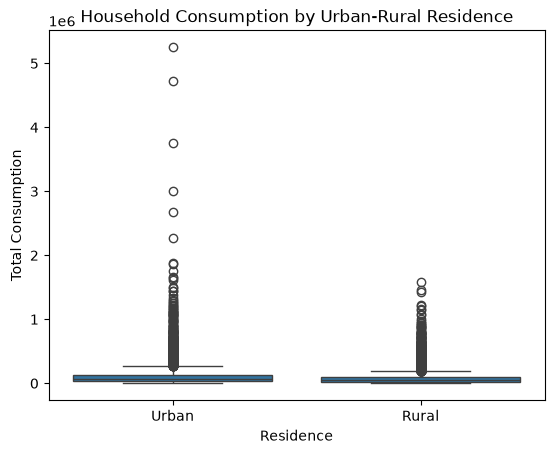

In [46]:
df["urban_rural"] = df[URBAN_RURAL]

sns.boxplot(
    data=df,
    x="urban_rural",
    y="total_consumption",
    order=["Urban", "Rural"]
)

plt.title("Household Consumption by Urban-Rural Residence")
plt.xlabel("Residence")
plt.ylabel("Total Consumption")
plt.show()

### Log Transformation to cure skeweness in data

In [47]:
df["log_consumption"] = np.log1p(df["total_consumption"])

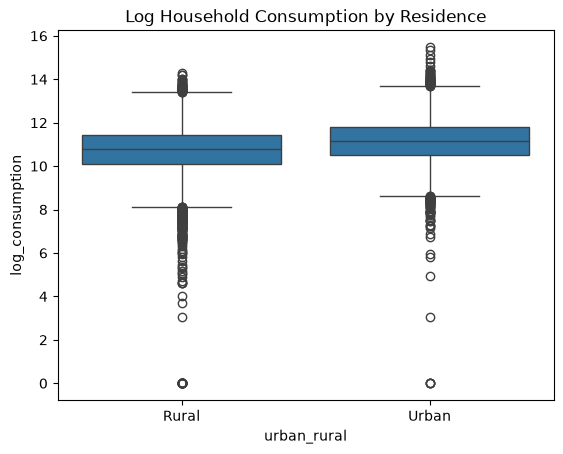

In [48]:
sns.boxplot(
    data=df,
    x="urban_rural",
    y="log_consumption"
)

plt.title("Log Household Consumption by Residence")
plt.show()

## Objective 1: Hypothesis Test

In [49]:
summary = (
    df.groupby("urban_rural")["total_consumption"]
    .agg(["count", "mean", "median", "std"])
)

summary

,count,mean,median,std
urban_rural,,,,
Rural,11419,77357.802737,48344.308594,98574.087296
Urban,5623,121750.661803,69802.156250,199086.071628


In [50]:
from scipy.stats import ttest_ind

urban = df.loc[
    df["urban_rural"] == "urban",
    "total_consumption"
].dropna()

rural = df.loc[
    df["urban_rural"] == "rural",
    "total_consumption"
].dropna()

test = ttest_ind(
    urban,
    rural,
    equal_var=False
)

print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)

t-statistic: nan
p-value: nan


/var/folders/sj/66l815lx6ld81wv6vcm5srgr0000gn/T/ipykernel_31933/3769147772.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  test = ttest_ind(


In [51]:
print(df["urban_rural"].value_counts(dropna=False))

urban_rural
Rural    11419
Urban     5623
Name: count, dtype: int64


In [53]:
print(df.groupby("urban_rural")["nonfood_consumption"].count())

urban_rural
Rural    11353
Urban     5609
Name: nonfood_consumption, dtype: int64


In [55]:
# fix for the KeyError
if "total_nonfood_consumption" not in df.columns:
    df["total_nonfood_consumption"] = df["nonfood_consumption"]

print(df["total_nonfood_consumption"].isna().sum())

80


In [57]:
from scipy.stats import ttest_ind

URBAN_CODE = "Urban"
RURAL_CODE = "Rural"

urban = df.loc[
    df["urban_rural"] == URBAN_CODE,
    "total_nonfood_consumption"
].dropna()

rural = df.loc[
    df["urban_rural"] == RURAL_CODE,
    "total_nonfood_consumption"
].dropna()

test = ttest_ind(urban, rural, equal_var=False)

print("Urban households:", len(urban))
print("Rural households:", len(rural))
print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)

Urban households: 5609
Rural households: 11353
t-statistic: 15.565491
p-value: 0.0


In [58]:
alpha = 0.05

if test.pvalue < alpha:
    print("Reject H0: significant difference.")
else:
    print("Fail to reject H0.")

Reject H0: significant difference.


### Effect Size just going beyond the P-Value

In [59]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_sd = np.sqrt(
        ((nx - 1) * x.var(ddof=1) +
         (ny - 1) * y.var(ddof=1))
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_sd


d = cohens_d(urban, rural)

print("Cohen's d:", d)

Cohen's d: 0.3129322


### A/B Testing

In [60]:
mean_A = urban.mean()
mean_B = rural.mean()

difference = mean_A - mean_B

print("Group A mean:", mean_A)
print("Group B mean:", mean_B)
print("Difference:", difference)

Group A mean: 119898.09
Group B mean: 76264.125
Difference: 43633.97


#### The A/B-style analysis compares observed consumption outcomes between urban and rural households. Because KCHS is observational rather than a randomized experiment, the analysis identifies association rather than causal treatment effects.

- The A/B test showed that Group A had higher average non-food consumption (119,898.09) than Group B (76,264.13), with a difference of 43,633.97 (57.2% higher). The difference was statistically significant, t = 15.565, p < .001, but the Cohen’s d = 0.313 indicates a small practical effect. Overall, Group A consumed significantly more than Group B, although the magnitude of the difference was modest.

### Objective 2: Examine Relationship using Correlation

In [66]:
HOUSEHOLD_SIZE = "PUT_ACTUAL_HOUSEHOLD_SIZE_VARIABLE_HERE"
HOUSEHOLD_INCOME = "PUT_ACTUAL_INCOME_VARIABLE_HERE"

In [68]:
HOUSEHOLD_SIZE = "hhsize_x"
HOUSEHOLD_INCOME = "padqexp"

correlation = df[
    [HOUSEHOLD_SIZE, HOUSEHOLD_INCOME, "total_consumption"]
].corr()

print(correlation)

                   hhsize_x   padqexp  total_consumption
hhsize_x           1.000000 -0.178203           0.190235
padqexp           -0.178203  1.000000           0.721815
total_consumption  0.190235  0.721815           1.000000


- Brief interpretation
- Household size and total consumption: weak positive correlation (r = 0.190).
- Adult-equivalent expenditure and total consumption: strong positive correlation (r = 0.722).
- Household size and adult-equivalent expenditure: weak negative correlation (r = −0.178).
Overall: Adult-equivalent expenditure has the strongest relationship with total consumption, while household size has only a weak relationship. Correlation indicates association, not causation.

## Deployment: Streamlit

In [69]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(
    output_dir / "analysis_dataset.csv",
    index=False
)

print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.


## Visualizations

Dataset shape: (17042, 61)
   clid_x  strid  hhid county_x resid_x  strat_x        a11_1  e1  e2  e3  \
0     1.0    1.0   1.0  Mombasa   Urban        1  Non-farming   2   2   1   
1     1.0    2.0   2.0  Mombasa   Urban        1  Non-farming   1   1   1   
2     1.0    3.0   3.0  Mombasa   Urban        1  Non-farming   1   1   1   
3     1.0    4.0   4.0  Mombasa   Urban        1  Non-farming   2   2   1   
4     1.0    5.0   5.0  Mombasa   Urban        1  Non-farming   2   2   1   

        e4               e5                        e6  \
0     FLAT  PAYS RENT/LEASE  Concrete/ Cement/Terrazo   
1  SWAHILI  PAYS RENT/LEASE       Wall to wall Carpet   
2  SWAHILI  PAYS RENT/LEASE       Wall to wall Carpet   
3     FLAT  PAYS RENT/LEASE  Concrete/ Cement/Terrazo   
4     FLAT  PAYS RENT/LEASE             Ceramic tiles   

                            e7                      e8                    e9  \
0  Iron sheets/Decra/Versatile  Stone with lime/cement  Public tap/Standpipe   
1  Iron

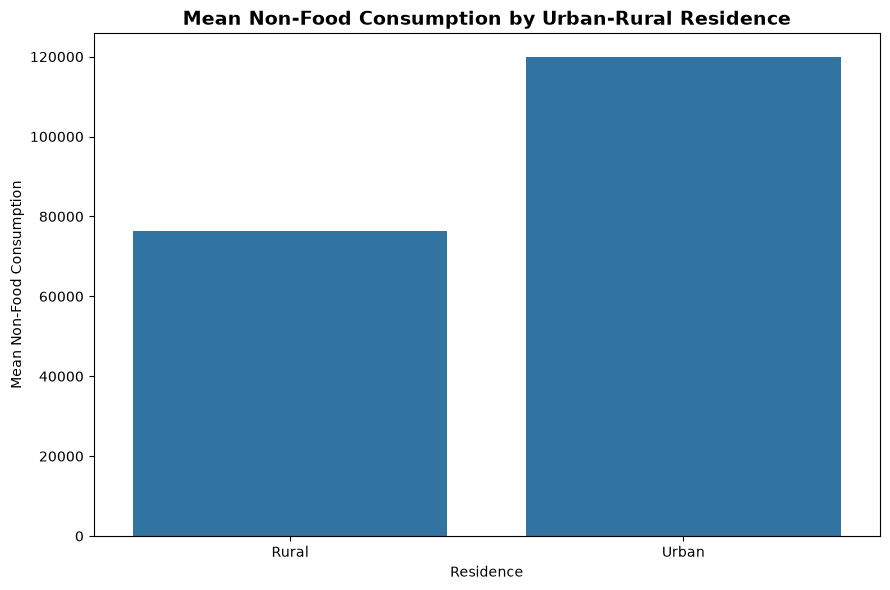

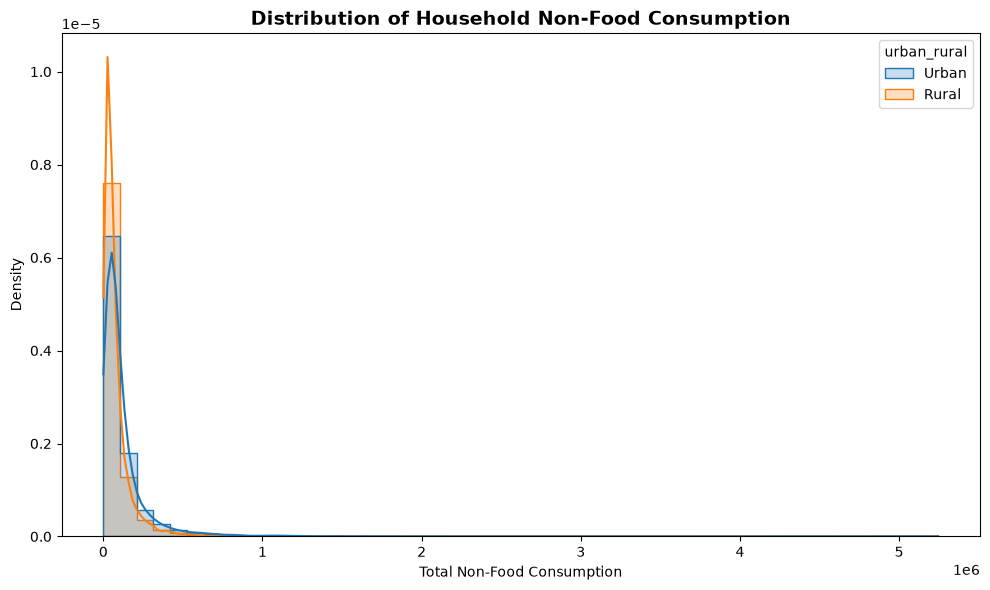

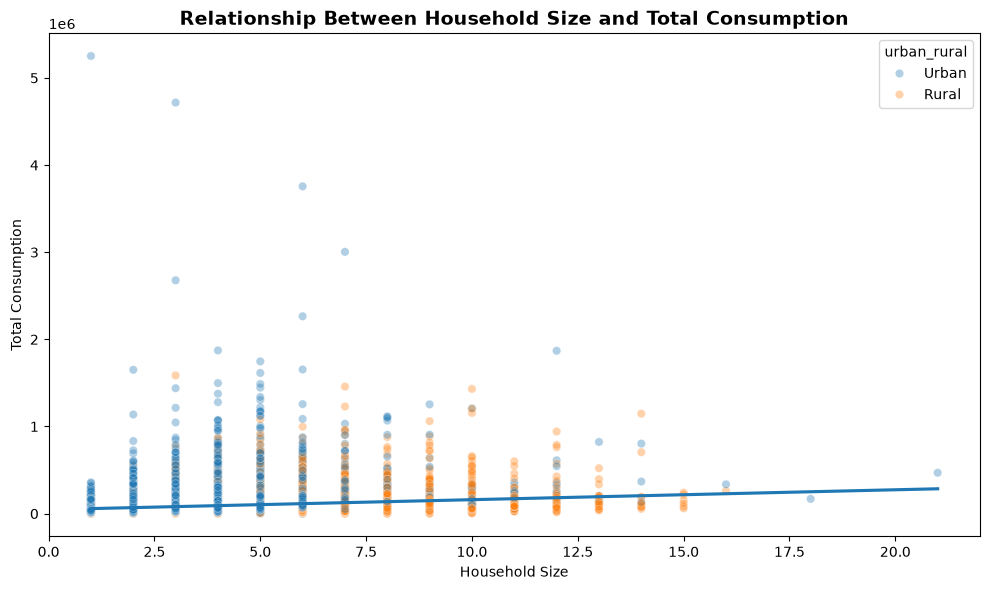

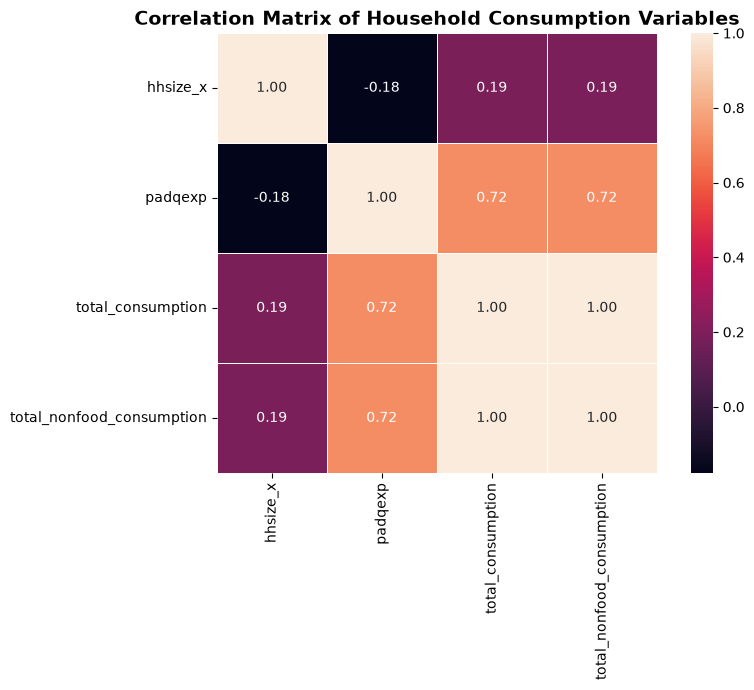

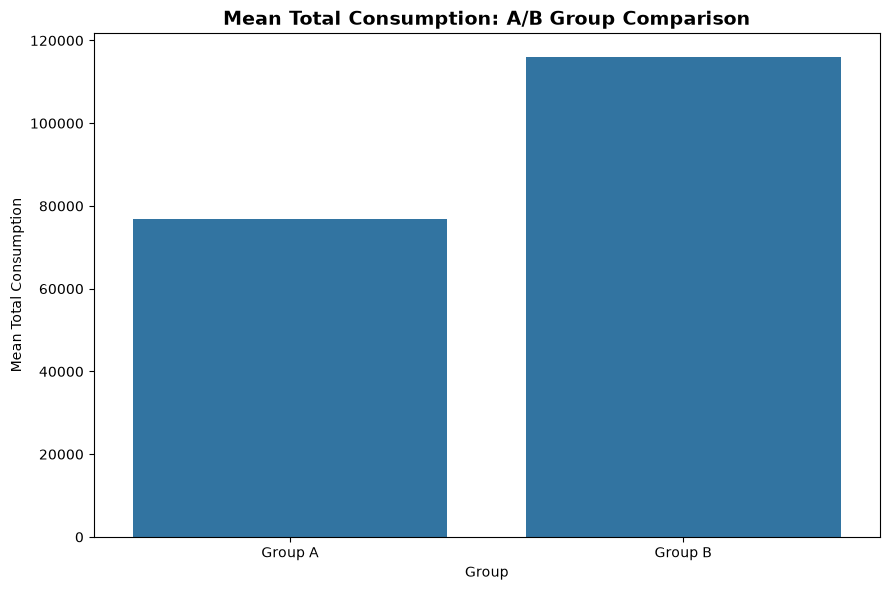


Five final figures have been saved to:
figures/

Files created:
1. figure1_urban_rural_consumption.png
2. figure2_consumption_distribution.png
3. figure3_household_size_consumption.png
4. figure4_correlation_heatmap.png
5. figure5_ab_comparison.png


In [71]:
# ============================================================
# FINAL ACADEMIC / PROFESSIONAL FIGURES
# Urban-Rural Consumption Capstone
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

processed_file = output_dir / "analysis_dataset.csv"

if processed_file.exists():
    df = pd.read_csv(processed_file)
elif "df" in globals():
    print("Using existing df already loaded in the notebook.")
else:
    raise FileNotFoundError(f"Dataset not found: {processed_file}")

print("Dataset shape:", df.shape)
print(df.head())

print("Dataset shape:", df.shape)
print(df.head())


# ------------------------------------------------------------
# 2. Create figures folder if necessary
# ------------------------------------------------------------

import os
from pathlib import Path

os.makedirs("figures", exist_ok=True)


# ============================================================
# FIGURE 1
# Urban vs Rural Mean Non-Food Consumption
# ============================================================

urban_rural = (
    df.groupby("urban_rural")["total_nonfood_consumption"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=urban_rural,
    x="urban_rural",
    y="mean"
)

plt.title(
    "Mean Non-Food Consumption by Urban-Rural Residence",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Residence")
plt.ylabel("Mean Non-Food Consumption")

plt.tight_layout()

plt.savefig(
    "figures/figure1_urban_rural_consumption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2
# Distribution of Non-Food Consumption
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total_nonfood_consumption",
    hue="urban_rural",
    kde=True,
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Distribution of Household Non-Food Consumption",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Non-Food Consumption")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    "figures/figure2_consumption_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3
# Household Size vs Total Consumption
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="hhsize_x",
    y="total_consumption",
    hue="urban_rural",
    alpha=0.35
)

sns.regplot(
    data=df,
    x="hhsize_x",
    y="total_consumption",
    scatter=False,
    ci=None
)

plt.title(
    "Relationship Between Household Size and Total Consumption",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Household Size")
plt.ylabel("Total Consumption")

plt.tight_layout()

plt.savefig(
    "figures/figure3_household_size_consumption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4
# Correlation Heatmap
# ============================================================

correlation_variables = [
    "hhsize_x",
    "padqexp",
    "total_consumption",
    "total_nonfood_consumption"
]

corr = df[correlation_variables].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Household Consumption Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/figure4_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 5
# A/B Group Comparison
# ============================================================

# Replace these group labels with the actual grouping variable
# used in your A/B analysis if it is stored in the dataset.

# Example: create two groups using the median household size.
median_size = df["hhsize_x"].median()

df["AB_group"] = np.where(
    df["hhsize_x"] <= median_size,
    "Group A",
    "Group B"
)

ab_summary = (
    df.groupby("AB_group")["total_consumption"]
      .agg(["mean", "count"])
      .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=ab_summary,
    x="AB_group",
    y="mean"
)

plt.title(
    "Mean Total Consumption: A/B Group Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Group")
plt.ylabel("Mean Total Consumption")

plt.tight_layout()

plt.savefig(
    "figures/figure5_ab_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nFive final figures have been saved to:")
print("figures/")

print("\nFiles created:")

print("1. figure1_urban_rural_consumption.png")
print("2. figure2_consumption_distribution.png")
print("3. figure3_household_size_consumption.png")
print("4. figure4_correlation_heatmap.png")
print("5. figure5_ab_comparison.png")